# Fruit Quality Classification

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from keras.api import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.api.utils import to_categorical

### Define directories

In [6]:
bad_quality_dir = '../data/Processed Images_Fruits/Bad Quality_Fruits'
good_quality_dir = '../data/Processed Images_Fruits/Good Quality_Fruits'
mixed_quality_dir = '../data/Processed Images_Fruits/Mixed Quality_Fruits'

In [7]:
# Process image data
file_paths = []
labels = []

In [8]:
# Define a function to process directories and extract file paths and labels
def process_directory(directory, file_paths, labels):
    """
    Scans a directory structure and extracts image file paths and labels
    
    Args:
        directory: The root directory to process
        file_paths: List to append file paths to
        labels: List to append corresponding labels to
    """
    # Loop through each subfolder (fruit type) in the directory
    for subfolder_name in os.listdir(directory):
        subfolder_path = os.path.join(directory, subfolder_name)
        if os.path.isdir(subfolder_path):  # Check if it's a directory
            # Loop through each file in the subfolder
            for file_name in os.listdir(subfolder_path):
                # Only process image files
                if file_name.endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(subfolder_path, file_name)
                    file_paths.append(file_path)
                    
                    # Create label based on fruit type and quality
                    # If it's from mixed_quality_dir, append "_mixed" to the label
                    label = f"{subfolder_name}_mixed" if directory == mixed_quality_dir else subfolder_name
                    labels.append(label)

In [9]:
# Process all directories to collect file paths and labels
process_directory(bad_quality_dir, file_paths, labels)
process_directory(good_quality_dir, file_paths, labels)
process_directory(mixed_quality_dir, file_paths, labels)

In [10]:
# Print some statistics about collected data
print(f"Total images: {len(file_paths)}")
print(f"Sample labels: {labels[:5]}")

Total images: 15819
Sample labels: ['Guava_Bad', 'Guava_Bad', 'Guava_Bad', 'Guava_Bad', 'Guava_Bad']


In [11]:
# Use LabelEncoder to convert text labels to numeric values
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [12]:
# Store the original text labels for later reference
original_text_labels = label_encoder.classes_
print(f"Unique classes: {len(original_text_labels)}")
print(f"Classes: {original_text_labels}")

Unique classes: 18
Classes: ['Apple_Bad' 'Apple_Good' 'Apple_mixed' 'Banana_Bad' 'Banana_Good'
 'Banana_mixed' 'Guava_Bad' 'Guava_Good' 'Guava_mixed' 'Lemon_mixed'
 'Lime_Bad' 'Lime_Good' 'Orange_Bad' 'Orange_Good' 'Orange_mixed'
 'Pomegranate_Bad' 'Pomegranate_Good' 'Pomegranate_mixed']


In [13]:
# Create a DataFrame to organize file paths and their corresponding encoded labels
combined_data = pd.DataFrame({
    'file_path': file_paths,
    'label': encoded_labels,
    'text_label': labels  # Keep original text labels for reference
})

In [14]:
# Resize images function
def resize_image(image_path, target_size=(150, 150)):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Failed to load image: {image_path}")
        return None
    resized_image = cv2.resize(image, target_size)
    return resized_image

In [15]:
# Resize all images
resized_images = []
valid_indices = []  # Keep track of valid indices

In [16]:
for index, row in combined_data.iterrows():
    file_path = row['file_path']
    resized_image = resize_image(file_path, target_size=(100, 100))
    if resized_image is not None:
        resized_images.append(resized_image)
        valid_indices.append(index)

In [17]:
# Filter combined_data to keep only rows with successfully loaded images
combined_data = combined_data.iloc[valid_indices].reset_index(drop=True)

In [18]:
resized_images_array = np.array(resized_images)
print(f"Total resized images: {len(resized_images_array)}")

Total resized images: 15819


In [19]:
# FIXED: Use the already encoded labels from combined_data
# No need to re-encode since they're already numbers
labels = combined_data['label'].values

In [20]:
# Split data
X_train, X_rem, y_train, y_rem = train_test_split(
    resized_images_array, labels, test_size=0.4, random_state=42, stratify=labels
)

In [21]:
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

In [22]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 9491
Validation set size: 3164
Test set size: 3164


In [23]:
# Count number of unique classes
num_classes = len(np.unique(labels))
print(f"Number of classes: {num_classes}")

Number of classes: 18


In [24]:
# Convert to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_val_one_hot = to_categorical(y_val, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

In [25]:
print(f"y_train shape: {y_train_one_hot.shape}")
print(f"y_val shape: {y_val_one_hot.shape}")

y_train shape: (9491, 18)
y_val shape: (3164, 18)


In [26]:
# Define model function
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(previous_block_activation)
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Always use multi-class output with the correct number of classes
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

In [27]:
# Define input shape
input_shape = (100, 100, 3)

In [28]:
# Create model with correct number of classes
model = make_model(input_shape=input_shape, num_classes=num_classes)

In [29]:
# Setup callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("save_at_{epoch}.keras"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
]

In [30]:
# Compile model with categorical_crossentropy for multi-class classification
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Use categorical_crossentropy for one-hot encoded labels
    metrics=['accuracy']
)

In [31]:
# Train model
epochs = 10
history = model.fit(
    X_train,
    y_train_one_hot,  # Use one-hot encoded labels
    batch_size=64,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=(X_val, y_val_one_hot)  # Use one-hot encoded validation labels
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 108s 714ms/step - accuracy: 0.6730 - loss: 1.1124 - val_accuracy: 0.0812 - val_loss: 2.6381
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 109s 730ms/step - accuracy: 0.8831 - loss: 0.3708 - val_accuracy: 0.2263 - val_loss: 2.5864
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 111s 746ms/step - accuracy: 0.9160 - loss: 0.2549 - val_accuracy: 0.1078 - val_loss: 3.3278
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 112s 750ms/step - accuracy: 0.9397 - loss: 0.1758 - val_accuracy: 0.3903 - val_loss: 2.2664
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 114s 763ms/step - accuracy: 0.9429 - loss: 0.1679 - val_accuracy: 0.8935 - val_loss: 0.3151
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 112s 754ms/step - accuracy: 0.9637 - loss: 0.1139 - val_accuracy: 0.7829 - val_loss: 0.7993
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 117s 783ms/step - accuracy: 0.9813 - loss: 0.0680 - val_accuracy: 0.9200 - val_loss: 0.2241
Epoch 8/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 115s 772ms/step - accuracy: 0.9737 -

In [32]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test_one_hot)
print(f"Test Loss: {test_loss}") #loss is the error rate of the model
print(f"Test Accuracy: {test_acc}") #accuracy is the rate of correct predictions

99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.8938 - loss: 0.3211
Test Loss: 0.33362653851509094
Test Accuracy: 0.9001263976097107


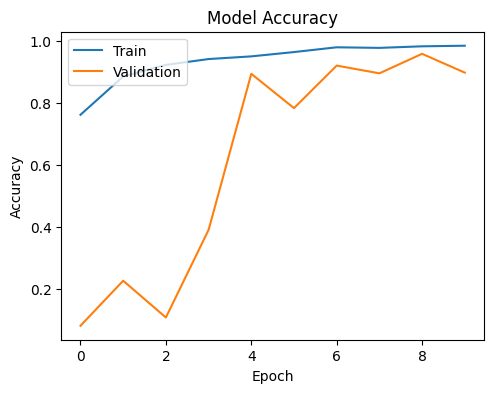

In [33]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

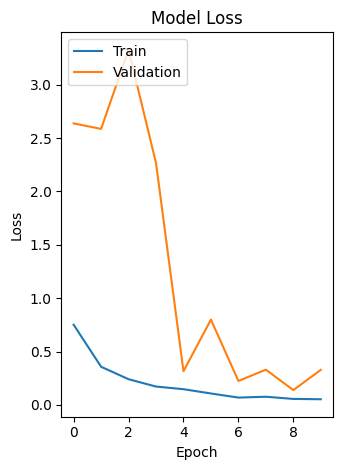

In [34]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

In [35]:
# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test_one_hot, axis=1)

99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step


In [36]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

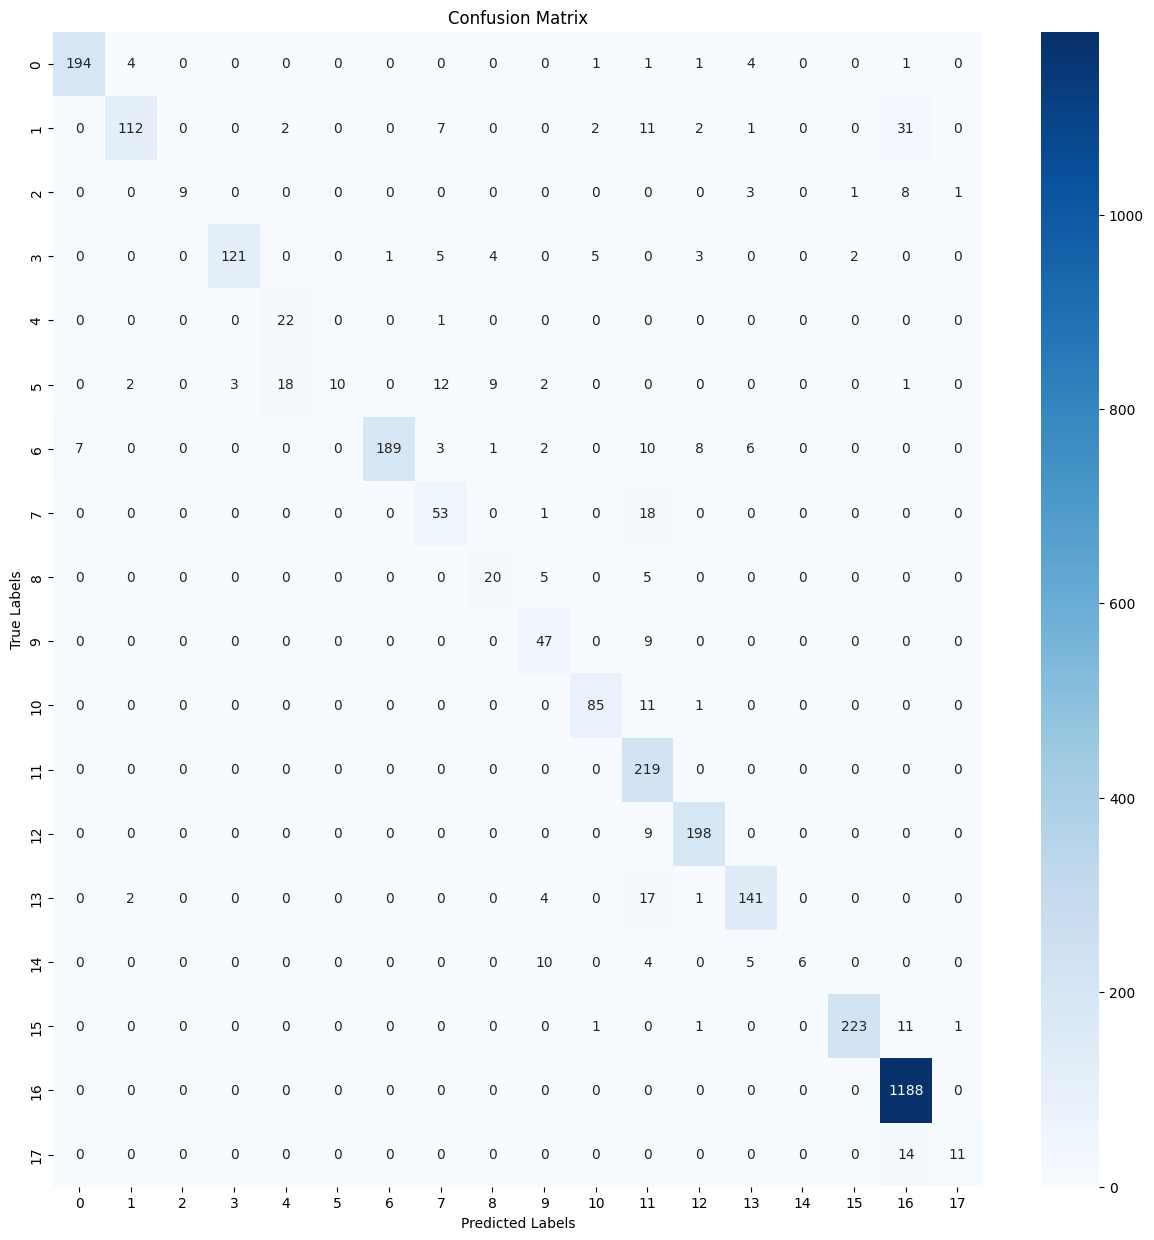

In [37]:
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

In [38]:
# Print classification report with proper class names
# Map numeric class IDs to meaningful names
class_names = label_encoder.classes_
target_names = [class_names[i] for i in range(len(class_names))]
print(classification_report(y_test_classes, y_pred_classes, target_names=target_names))

                   precision    recall  f1-score   support

        Apple_Bad       0.97      0.94      0.95       206
       Apple_Good       0.93      0.67      0.78       168
      Apple_mixed       1.00      0.41      0.58        22
       Banana_Bad       0.98      0.86      0.91       141
      Banana_Good       0.52      0.96      0.68        23
     Banana_mixed       1.00      0.18      0.30        57
        Guava_Bad       0.99      0.84      0.91       226
       Guava_Good       0.65      0.74      0.69        72
      Guava_mixed       0.59      0.67      0.62        30
      Lemon_mixed       0.66      0.84      0.74        56
         Lime_Bad       0.90      0.88      0.89        97
        Lime_Good       0.70      1.00      0.82       219
       Orange_Bad       0.92      0.96      0.94       207
      Orange_Good       0.88      0.85      0.87       165
     Orange_mixed       1.00      0.24      0.39        25
  Pomegranate_Bad       0.99      0.94      0.96       

In [39]:
# Save the best model based on validation accuracy
best_model_path = "fruit_quality_model.keras"
model.save(best_model_path)
print(f"Saved best model to {best_model_path}")

Saved best model to fruit_quality_model.keras


In [40]:
# Define class names for later reference
# Use the original label encoder's classes
class_names = label_encoder.classes_
np.save('class_names.npy', class_names)
print(f"Saved {len(class_names)} class names")

Saved 18 class names


In [41]:
# Save labels file for Android
with open('labels.txt', 'w') as f:
    for class_name in class_names:
        f.write(f"{class_name}\n")
print("Labels file saved as labels.txt")

Labels file saved as labels.txt


In [42]:
# Print the class mapping for reference
print("\nClass mapping:")
for i, class_name in enumerate(class_names):
    print(f"  {i}: {class_name}")


Class mapping:
  0: Apple_Bad
  1: Apple_Good
  2: Apple_mixed
  3: Banana_Bad
  4: Banana_Good
  5: Banana_mixed
  6: Guava_Bad
  7: Guava_Good
  8: Guava_mixed
  9: Lemon_mixed
  10: Lime_Bad
  11: Lime_Good
  12: Orange_Bad
  13: Orange_Good
  14: Orange_mixed
  15: Pomegranate_Bad
  16: Pomegranate_Good
  17: Pomegranate_mixed


In [43]:
# Convert the model to TFLite format (which is compatible with LiteRT)
print("\nConverting model to TFLite/LiteRT format...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)


Converting model to TFLite/LiteRT format...


In [44]:
# Optimize for size and latency
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [45]:
# Enable quantization for further size reduction
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, 
                                      tf.lite.OpsSet.SELECT_TF_OPS]

In [46]:
# Convert the model
lite_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/jn/c7fwgt3d7fx2fbbc3n3v4ddh0000gn/T/tmp45c_utkq/assets


INFO:tensorflow:Assets written to: /var/folders/jn/c7fwgt3d7fx2fbbc3n3v4ddh0000gn/T/tmp45c_utkq/assets


Saved artifact at '/var/folders/jn/c7fwgt3d7fx2fbbc3n3v4ddh0000gn/T/tmp45c_utkq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 18), dtype=tf.float32, name=None)
Captures:
  13553211088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553213584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553213008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553214160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553211664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553212240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553213392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553211856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553212624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13553214928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135532139

W0000 00:00:1743461210.119959 1369055 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1743461210.120170 1369055 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-03-31 17:46:50.120344: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/jn/c7fwgt3d7fx2fbbc3n3v4ddh0000gn/T/tmp45c_utkq
2025-03-31 17:46:50.121674: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-03-31 17:46:50.121678: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/jn/c7fwgt3d7fx2fbbc3n3v4ddh0000gn/T/tmp45c_utkq
I0000 00:00:1743461210.134835 1369055 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-03-31 17:46:50.137300: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-03-31 17:46:50.234407: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folder

In [47]:
# Save the model to a file
lite_model_path = "fruit_quality_model.tflite"
with open(lite_model_path, 'wb') as f:
    f.write(lite_model)
print(f"Model saved as TFLite/LiteRT compatible format at: {lite_model_path}")

Model saved as TFLite/LiteRT compatible format at: fruit_quality_model.tflite


In [48]:
print("\nConversion completed. Files saved:")
print(f"  - Model: {lite_model_path}")
print(f"  - Class names: class_names.npy")
print(f"  - Labels: labels.txt")


Conversion completed. Files saved:
  - Model: fruit_quality_model.tflite
  - Class names: class_names.npy
  - Labels: labels.txt
